# Notebook 1 — EDA & Preprocessing

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 1. Load Raw Data

In [8]:
mort = pd.read_csv('../data/Mortality_US_by_County_All_Races_All_Malignant_Cancers_(Both_Sexes)_2019_-_2023.csv', skiprows=1)
svi  = pd.read_csv('../data/SVI_2022_US_county.csv')
incd = pd.read_csv('../data/incd.csv', skiprows=8, on_bad_lines='skip')

print('Mortality shape:', mort.shape)
print('SVI shape:      ', svi.shape)
print('Incidence shape:', incd.shape)

Mortality shape: (2000, 6)
SVI shape:       (3144, 158)
Incidence shape: (3161, 14)


## 2. Clean Mortality Data

In [9]:
mort.columns = ['Area','FIPS','rate','lower','upper','count']
mort = mort[mort['FIPS'] != '00000']
mort = mort[~mort['rate'].isin(['No Data', 'Suppressed', 'Not Applicable'])]
mort['FIPS'] = mort['FIPS'].astype(str).str.zfill(5)
mort['rate'] = pd.to_numeric(mort['rate'], errors='coerce')
mort.dropna(subset=['rate'], inplace=True)
print('Mortality after cleaning:', mort.shape)
mort[['Area','rate']].head()

Mortality after cleaning: (2000, 6)


,Area,rate
0,"Union, Florida",412.24
1,"Kingman, Kansas",359.67
2,"Todd, South Dakota",273.95
3,"Galax, Virginia",273.07
4,"Humphreys, Mississippi",269.22


## 3. Merge with SVI

In [10]:
svi['FIPS'] = svi['FIPS'].astype(str).str.zfill(5)
ep = [c for c in svi.columns if c.startswith('EP_')]
df = mort[['FIPS','Area','rate']].merge(svi[['FIPS'] + ep], on='FIPS')
print('After merge with SVI:', df.shape)

After merge with SVI: (1998, 27)


## 4. Merge with Incidence Data

In [12]:
incd.columns = ['County','FIPS','RuralUrban','IncidenceRate',
                'IncLower','IncUpper','CIRank','CRLower','CRUpper',
                'AvgCount','RecentTrend','Trend5yr','TLower','TUpper']
incd = incd[~incd['IncidenceRate'].isin(['NA','Suppressed','Not Applicable','No Data'])]
incd['FIPS'] = incd['FIPS'].astype(str).str.replace('.0','',regex=False).str.zfill(5)
incd = incd[incd['FIPS'] != '00000']
incd['IncidenceRate'] = pd.to_numeric(incd['IncidenceRate'], errors='coerce')
incd.dropna(subset=['IncidenceRate'], inplace=True)

df2 = df.merge(incd[['FIPS','IncidenceRate']], on='FIPS', how='inner')
print('After merge with incidence:', df2.shape)

After merge with incidence: (1933, 28)


## 5. Data Leakage Check

In [13]:
feature_cols = ep + ['IncidenceRate']
leakage_candidates = [
    col for col in feature_cols
    if any(kw in col.lower() for kw in ['rate','count','death','mort','lower','upper'])
    and col != 'IncidenceRate'
]
print('Potential leakage candidates:', leakage_candidates)
print('IncidenceRate is retained: clinically distinct (diagnosis rate, not death rate).')

Potential leakage candidates: []
IncidenceRate is retained: clinically distinct (diagnosis rate, not death rate).


## 6. EDA


count    1933.000000
mean      178.699488
std        21.249133
min       152.430000
25%       163.020000
50%       173.990000
75%       188.950000
max       412.240000
Name: rate, dtype: float64


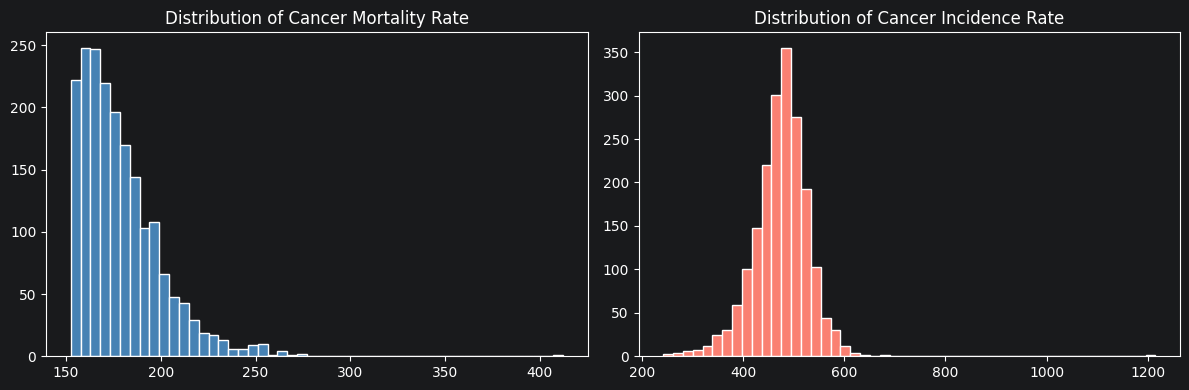

Saved: data/processed_merged.csv


In [14]:
print(df2['rate'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df2['rate'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Cancer Mortality Rate')
axes[1].hist(df2['IncidenceRate'], bins=50, color='salmon', edgecolor='white')
axes[1].set_title('Distribution of Cancer Incidence Rate')
plt.tight_layout()
plt.savefig('../visualizations/eda_distributions.png', dpi=150)
plt.show()

df2.to_csv('../data/processed_merged.csv', index=False)
print('Saved: data/processed_merged.csv')